# 1D k-Nearest Neighbors Regression from Scratch

To better understand the **k-Nearest Neighbors (k-NN)** algorithm, we'll build a k-NN regressor manually to grok how it makes predictions.

We'll:
1. Generate synthetic data with some added noise
2. Implement the k-NN regressor
3. Visualize weighted/unweighted results using different $k$ values
3. Find the optimal $k$

Let's start with some synthetic sine wave data:

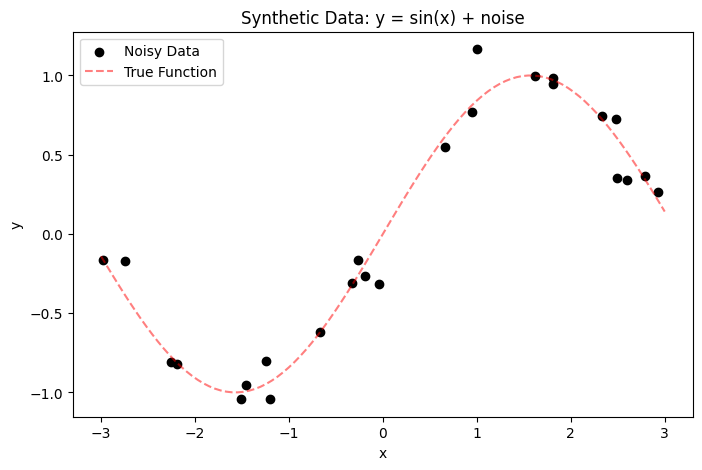

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate synthetic data
np.random.seed(2025)
x = np.random.uniform(-3, 3, size=25)
y = np.sin(x)
e = np.random.normal(0, 0.15, size=25)
y += e  # Add noise

# 2. Visualize the raw data
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='k', label='Noisy Data')
plt.plot(np.linspace(-3, 3, 100), np.sin(np.linspace(-3, 3, 100)), 'r--', alpha=0.5, label='True Function')
plt.title('Synthetic Data: y = sin(x) + noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

The k-NN regression algorithm works in four main steps for a given prediction:

1.  **Distance:** Calculate the distance between the query $x$ and all training $x$ values
2.  **Sort:** Sort the training points by distance to find the closest ones
3.  **Select:** Select the top $k$ nearest neighbors
4.  **Aggregate:** Compute the average $y$ values of these neighbors.
    *   *Unweighted:* A simple average
    *   *Weighted:* A weighted average giving more weight to closer neighbors 

In [7]:
def knn_regress_1d(x_train, y_train, x_query, k, weighted=False):
    """
    x_train: array of x values you already know
    y_train: array of y values you already know
    x_query: array of x values you want predictions for
    k: how many neighbors to use
    weighted: whether closer neighbors should count more
    """

    y_query = []

    for x in x_query:
        # 1. Distance
        diff = abs(x_train - x)

        # 2. Sort
        sorted_indices = np.argsort(diff)

        # 3. Select
        k_indices = sorted_indices[:k]

        # 4. Aggregate
        if weighted:
            weights = 1 / (diff[k_indices] + 1e-8) # avoid division by zero
            y_query.append(np.average(y_train[k_indices], weights=weights))
        else:
            y_query.append(np.mean(y_train[k_indices]))

    return np.array(y_query)

Let's plot some simple and weighted predictions with different $k$ values:

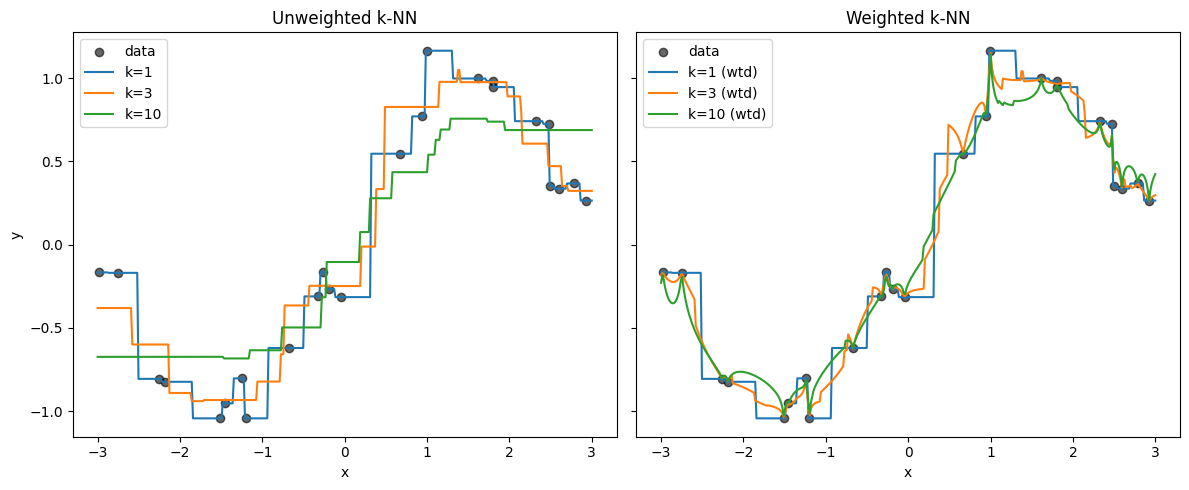

In [8]:
lin_vals = np.linspace(-3, 3, 400)

# Generate predictions for different k values
k1_preds = knn_regress_1d(x, y, lin_vals, k=1)
k3_preds = knn_regress_1d(x, y, lin_vals, k=3)
k10_preds = knn_regress_1d(x, y, lin_vals, k=10)

# Generate weighted predictions
k1_preds_wtd = knn_regress_1d(x, y, lin_vals, k=1, weighted=True)
k3_preds_wtd = knn_regress_1d(x, y, lin_vals, k=3, weighted=True)
k10_preds_wtd = knn_regress_1d(x, y, lin_vals, k=10, weighted=True)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left subplot: unweighted k-NN predictions
axs[0].scatter(x, y, color='k', label='data', alpha=0.6)
axs[0].plot(lin_vals, k1_preds, label='k=1', color='C0')
axs[0].plot(lin_vals, k3_preds, label='k=3', color='C1')
axs[0].plot(lin_vals, k10_preds, label='k=10', color='C2')
axs[0].set_title('Unweighted k-NN')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].legend()

# Right subplot: weighted k-NN predictions
axs[1].scatter(x, y, color='k', label='data', alpha=0.6)
axs[1].plot(lin_vals, k1_preds_wtd, label='k=1 (wtd)', color='C0')
axs[1].plot(lin_vals, k3_preds_wtd, label='k=3 (wtd)', color='C1')
axs[1].plot(lin_vals, k10_preds_wtd, label='k=10 (wtd)', color='C2')
axs[1].set_title('Weighted k-NN')
axs[1].set_xlabel('x')
axs[1].legend()

plt.tight_layout()
plt.show()

The choice of $k$ dramatically changes the prediction behavior:

*   **Low $k$:** Captures every fluctuation in the data, including noise. This overfits (*high variance*)
*   **High $k$:** Averages over a large region, smoothing out the curve but missing the peaks of the wave. This underfits (*high bias*)
*   **Weighted k-NN:** By weighting closer neighbors more heavily, we get more resolution with larger $k$ values

So how do we find the optimal $k$? When predicting continuous values, the task is to minimize the overall error between predicted and true values. To be rigorous, we can calculate the **Mean Squared Error (MSE)** between our predictions and the *true* underlying sine wave function.

Let's iterate through $k=1$ to $k=15$ using the weighted k-NN model and find the "sweet spot" that minimizes error.

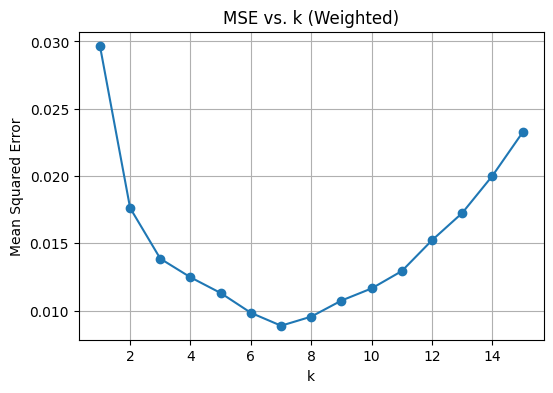

The optimal k is: 7


In [9]:
def get_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

errors = []
k_values = range(1, 16)

# We use the true sine wave as the ground truth for validation
y_true_func = np.sin(lin_vals)

for k in k_values:
    preds = knn_regress_1d(x, y, lin_vals, k=k, weighted=True)
    mse = get_mse(y_true_func, preds)
    errors.append(mse)

plt.figure(figsize=(6, 4))
plt.plot(k_values, errors, marker='o')
plt.title('MSE vs. k (Weighted)')
plt.xlabel('k')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

best_k = k_values[np.argmin(errors)]
print(f"The optimal k is: {best_k}")

So what did we learn?

1.  **Low $k$ Overfits:** With $k=1$, the model chases the noise in the training data
2.  **High $k$ Underfits:** Increasing $k$ smooths the prediction but, if $k$ is too large, the predictions fail to capture the true curvature of the sine wave.
3.  **Weighting Can Balance Stability with Resolution:** Giving more weight to closer neighbors allows us to utilize more data for stability while keeping the prediction locally relevant.
4.  **Minimize Error to Find the Optimal $k$:** By iterating over a range of $k$ values and plotting the MSE, we can find where the error is minimized.